<a href="https://colab.research.google.com/github/vgandred-cmyk/colab-notebooks/blob/main/AND%20gate(hard%20coded).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AND GATE SINGLE PERCEPTRON – HARD-CODED WEIGHTS
 Weights: W1=1.0, W2=1.0
 Bias: b=-1.5
 Equation: 1.0x1 + 1.0x2 + -1.5 > 0

PREDICTIONS
Input [0 0]  ->  Linear=-1.50  Prediction=0.0  Actual=0
Input [0 1]  ->  Linear=-0.50  Prediction=0.0  Actual=0
Input [1 0]  ->  Linear=-0.50  Prediction=0.0  Actual=0
Input [1 1]  ->  Linear=0.50  Prediction=1.0  Actual=1


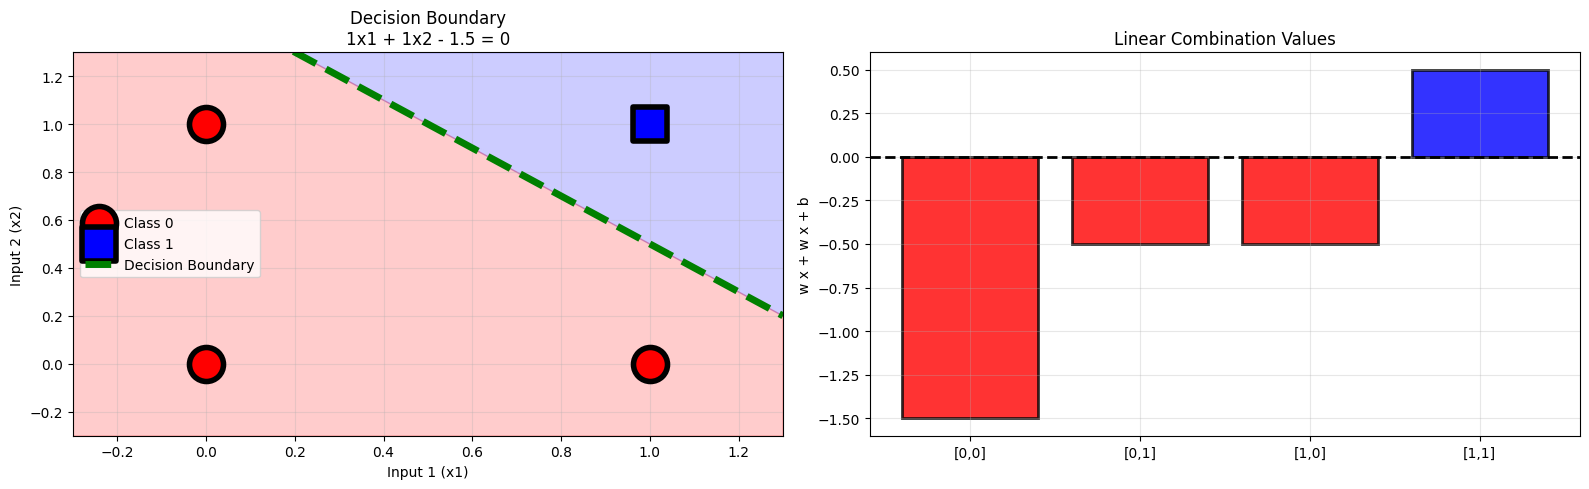


VERIFICATION RESULTS:
Decision boundary: x2 = (-x1 + 1.5)

Linear values for each input:
[0,0] : 1*0 + 1*0 - 1.5 = -1.5
   Class 0 (0)
[0,1] : 1*0 + 1*1 - 1.5 = -0.5
   Class 0 (0)
[1,0] : 1*1 + 1*0 - 1.5 = -0.5
   Class 0 (0)
[1,1] : 1*1 + 1*1 - 1.5 = 0.5
   Class 1 (>0)

Point positions relative to boundary:
[0,0] : -1.500 → Below (Class 0)
[0,1] : -0.500 → Below (Class 0)
[1,0] : -0.500 → Below (Class 0)
[1,1] : 0.500 → Above (Class 1)


In [1]:
# AND Gate using Single Perceptron (Hard-coded Weights)

import numpy as np
import matplotlib.pyplot as plt

# Input data
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [0],
              [0],
              [1]])

print("AND GATE SINGLE PERCEPTRON – HARD-CODED WEIGHTS")
print("="*60)

# Hard-coded weights
weights = np.array([[1.0],
                    [1.0]])

bias = np.array([[-1.5]])

print(f" Weights: W1={weights[0,0]:.1f}, W2={weights[1,0]:.1f}")
print(f" Bias: b={bias[0,0]:.1f}")
print(f" Equation: {weights[0,0]:.1f}x1 + {weights[1,0]:.1f}x2 + {bias[0,0]:.1f} > 0")


# Step activation function
def step_function(x):
    return 1 if x > 0 else 0


# Perceptron prediction
def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    predictions = np.zeros((4,1))

    for i in range(len(linear)):
        predictions[i,0] = step_function(linear[i,0])

    return predictions


# Sigmoid prediction (for visualization)
def sigmoid_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return 1/(1 + np.exp(-np.clip(linear,-250,250)))


print("\nPREDICTIONS")

linear_values = np.dot(X,weights) + bias
predictions = perceptron_predict(X,weights,bias)

for i in range(len(X)):
    linear_val = linear_values[i,0]
    pred = predictions[i][0]
    actual = y[i][0]

    print(f"Input {X[i]}  ->  Linear={linear_val:.2f}  Prediction={pred}  Actual={actual}")


# ======================
# VISUALIZATION
# ======================

plt.figure(figsize=(16,5))

# Plot points
plt.subplot(1,2,1)

plt.scatter(X[y.flatten()==0,0], X[y.flatten()==0,1],
            s=600, c='red', marker='o',
            edgecolors='black', linewidth=4,
            label='Class 0', zorder=3)

plt.scatter(X[y.flatten()==1,0], X[y.flatten()==1,1],
            s=600, c='blue', marker='s',
            edgecolors='black', linewidth=4,
            label='Class 1', zorder=4)

# Decision boundary
x1_range = np.linspace(-0.3,1.3,100)
x2_boundary = (-1.0*x1_range - (-1.5)) / 1.0

plt.plot(x1_range, x2_boundary,'g--',linewidth=5,
         label='Decision Boundary', zorder=2)

# Fill regions
plt.fill_between(x1_range,x2_boundary,1.3,alpha=0.2,color='blue')
plt.fill_between(x1_range,-0.3,x2_boundary,alpha=0.2,color='red')

plt.xlim(-0.3,1.3)
plt.ylim(-0.3,1.3)

plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('Decision Boundary\n1x1 + 1x2 - 1.5 = 0')

plt.legend()
plt.grid(True,alpha=0.3)


# ======================
# LINEAR VALUE GRAPH
# ======================

plt.subplot(1,2,2)

samples = ['[0,0]','[0,1]','[1,0]','[1,1]']
linear_vals = linear_values.flatten()

plt.bar(samples, linear_vals,
        color=['red','red','red','blue'],
        alpha=0.8,
        edgecolor='black',
        linewidth=2)

plt.axhline(y=0,color='black',linestyle='--',
            linewidth=2,label='Threshold')

plt.ylabel('w x + w x + b')
plt.title('Linear Combination Values')
plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()


# ======================
# VERIFICATION
# ======================

print("\nVERIFICATION RESULTS:")
print("Decision boundary: x2 = (-x1 + 1.5)")

print("\nLinear values for each input:")

for i in range(4):

    z = 1*X[i,0] + 1*X[i,1] - 1.5

    print(f"[{X[i,0]:.0f},{X[i,1]:.0f}] : 1*{X[i,0]:.0f} + 1*{X[i,1]:.0f} - 1.5 = {z:.1f}")

    print(f"   {'Class 1 (>0)' if z>0 else 'Class 0 (0)'}")


print("\nPoint positions relative to boundary:")

for i in range(len(X)):

    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]

    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"

    print(f"[{X[i,0]:.0f},{X[i,1]:.0f}] : {point_value:.3f} → {side}")